C:\Users\devis\AppData\Local\Temp\ipykernel_20304\2338148647.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


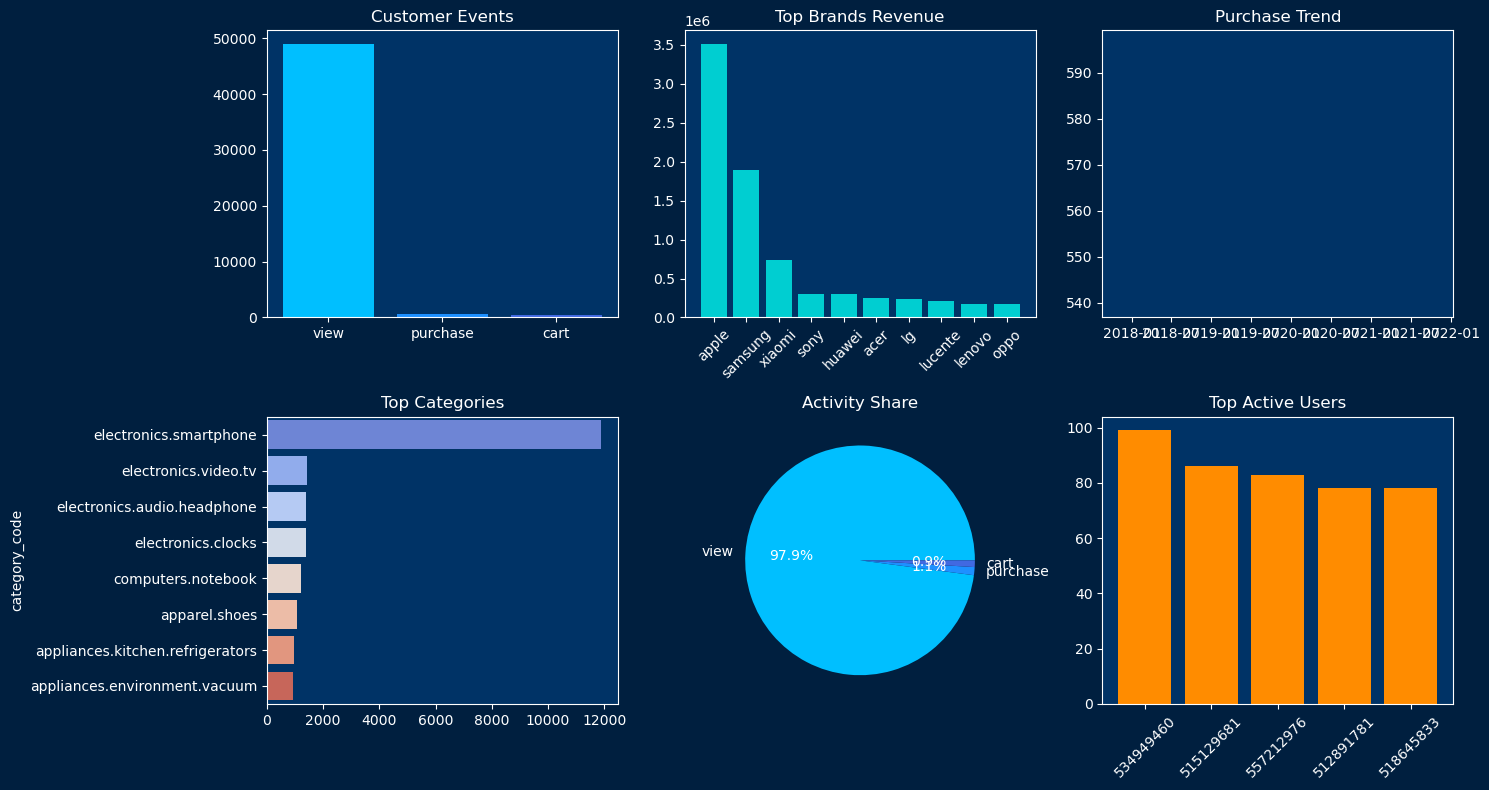

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"C:\Users\devis\OneDrive\Documents\future ds\FUTURE_DS_03\sample_ecommerce_data.csv")

# STYLE
plt.style.use('dark_background')

# CREATE FIGURE
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ==========================================
# 1. CUSTOMER EVENT DISTRIBUTION
# ==========================================

event_counts = df['event_type'].value_counts()

axes[0,0].bar(
    event_counts.index,
    event_counts.values,
    color=['#00BFFF', '#1E90FF', '#4169E1']
)

axes[0,0].set_title("Customer Events", color='white')

# ==========================================
# 2. TOP BRANDS BY REVENUE
# ==========================================

brand_df = df.dropna(subset=['brand'])

top_brands = brand_df.groupby('brand')['price'].sum() \
    .sort_values(ascending=False).head(10)

axes[0,1].bar(
    top_brands.index,
    top_brands.values,
    color='#00CED1'
)

axes[0,1].set_title("Top Brands Revenue", color='white')
axes[0,1].tick_params(axis='x', rotation=45)

# ==========================================
# 3. PURCHASE TREND ANALYSIS
# ==========================================

df['event_time'] = pd.to_datetime(df['event_time'])

purchase_df = df[df['event_type'] == 'purchase']

purchase_trend = purchase_df.groupby(
    purchase_df['event_time'].dt.date
).size()

axes[0,2].plot(
    purchase_trend.index,
    purchase_trend.values,
    color='#00FF7F',
    linewidth=3
)

axes[0,2].set_title("Purchase Trend", color='white')

# ==========================================
# 4. TOP PRODUCT CATEGORIES
# ==========================================

category_counts = df['category_code'].value_counts().head(8)

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    ax=axes[1,0],
    palette='coolwarm'
)

axes[1,0].set_title("Top Categories", color='white')

# ==========================================
# 5. CUSTOMER ACTIVITY SHARE
# ==========================================

axes[1,1].pie(
    event_counts.values,
    labels=event_counts.index,
    autopct='%1.1f%%',
    colors=['#00BFFF', '#1E90FF', '#4169E1']
)

axes[1,1].set_title("Activity Share", color='white')

# ==========================================
# 6. NEW CHART - TOP USERS
# ==========================================

top_users = df['user_id'].value_counts().head(5)

axes[1,2].bar(
    top_users.index.astype(str),
    top_users.values,
    color='#FF8C00'
)

axes[1,2].set_title("Top Active Users", color='white')
axes[1,2].tick_params(axis='x', rotation=45)

# ==========================================
# FINAL DESIGN
# ==========================================

fig.patch.set_facecolor('#001F3F')

for ax in axes.flat:
    ax.set_facecolor('#003366')

plt.tight_layout()

plt.show()